get the resolution information

In [1]:
from pathlib import Path
from PIL import Image
import pandas as pd

# image folder
image_dir = Path("../data/raw")

# valid extensions
valid_ext = [".png", ".jpg", ".jpeg", ".tif", ".bmp"]

records = []

# scan images
for path in image_dir.glob("**/*"):

    if path.suffix.lower() not in valid_ext:
        continue

    try:

        img = Image.open(path)

        width, height = img.size

        records.append({
            "path": str(path),
            "width": width,
            "height": height,
            "aspect_ratio": width / height,
            "megapixels": (width * height) / 1e6
        })

    except Exception as e:

        print(f"Error with {path}: {e}")

# dataframe
df = pd.DataFrame(records)

print(df.head())

                              path  width  height  aspect_ratio  megapixels
0  ..\data\raw\img10000_single.jpg   1721    1244      1.383441    2.140924
1  ..\data\raw\img10001_single.jpg   1720    1286      1.337481    2.211920
2       ..\data\raw\img10002_A.jpg   1557    1044      1.491379    1.625508
3       ..\data\raw\img10002_B.jpg   1557    1039      1.498556    1.617723
4       ..\data\raw\img10002_C.jpg   1570    1050      1.495238    1.648500


In [2]:
print(df[['width', 'height']].describe())

              width        height
count  47770.000000  47770.000000
mean    1304.737681   1012.884007
std      562.293997    410.508300
min       27.000000     27.000000
25%      945.000000    761.000000
50%     1183.000000    959.000000
75%     1512.000000   1187.000000
max     4700.000000   4534.000000


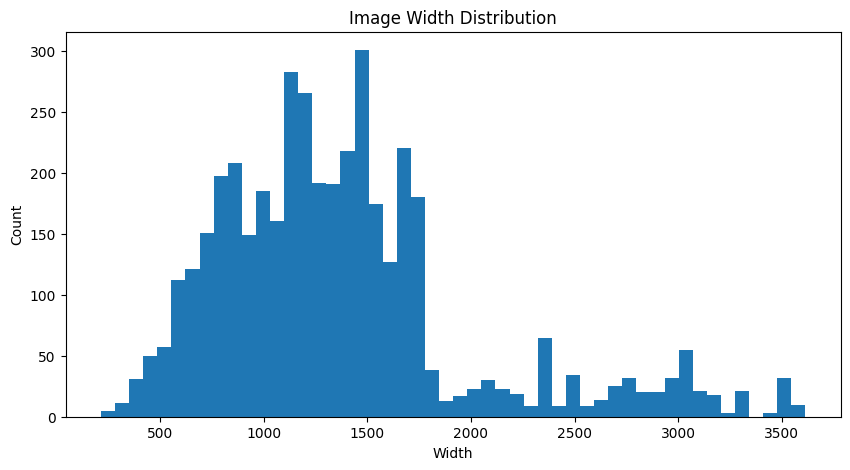

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df['width'], bins=50)

plt.title("Image Width Distribution")

plt.xlabel("Width")

plt.ylabel("Count")

plt.show()

aspect ratio analysis

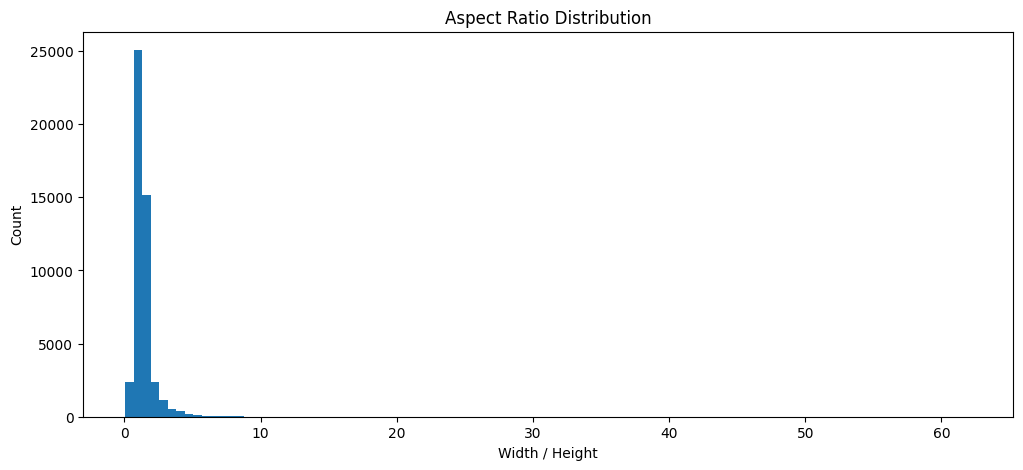

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.hist(df['aspect_ratio'], bins=100)

plt.title("Aspect Ratio Distribution")

plt.xlabel("Width / Height")

plt.ylabel("Count")

plt.show()